In [104]:
# Cargamos las librerias
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

# Cargamos el dataset
df = pd.read_csv('starbucks_customer_ordering_patterns.csv',parse_dates=['order_date'])
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M').dt.time

# Revisamos los datos
print(df.info())
print('---------------------')
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            100000 non-null  object        
 1   order_id               100000 non-null  object        
 2   order_date             100000 non-null  datetime64[ns]
 3   order_time             100000 non-null  object        
 4   day_of_week            100000 non-null  object        
 5   order_channel          100000 non-null  object        
 6   store_id               100000 non-null  object        
 7   store_location_type    100000 non-null  object        
 8   region                 100000 non-null  object        
 9   customer_age_group     100000 non-null  object        
 10  customer_gender        100000 non-null  object        
 11  is_rewards_member      100000 non-null  bool          
 12  cart_size              100000 non-null  int64

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47:00,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02:00,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40:00,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10:00,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38:00,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3


C:\Users\dario\AppData\Local\Temp\ipykernel_14128\4275391288.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='order_channel', y='fulfillment_time_min', data=df, ax=axes[1, 1], palette='Set3')


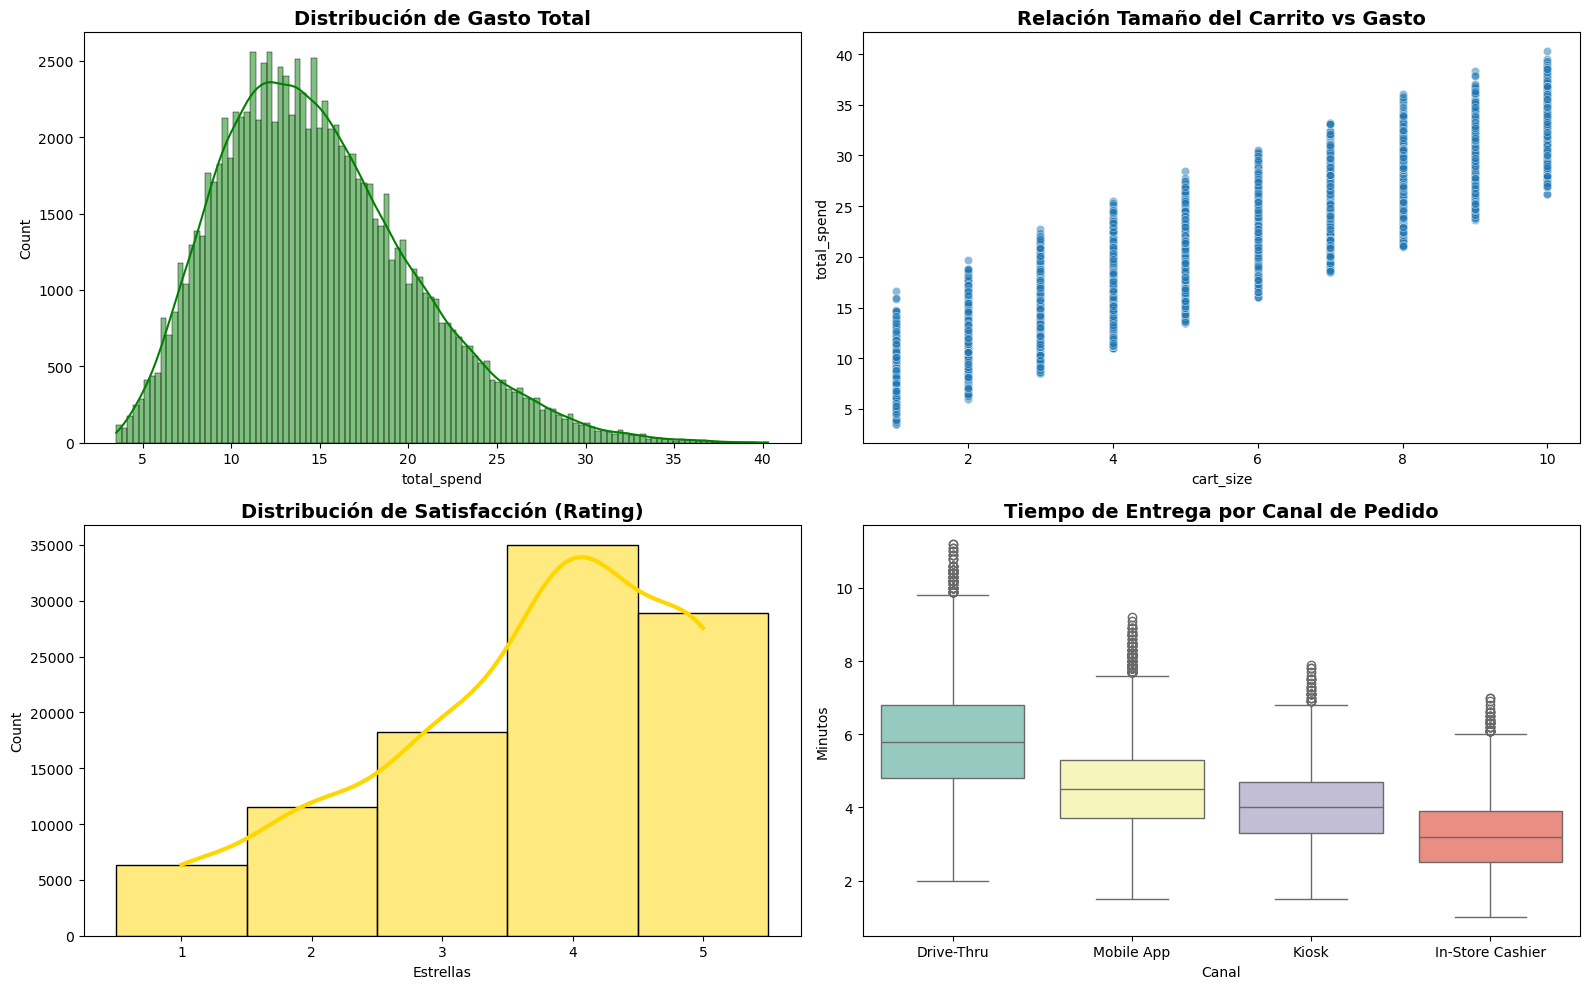

In [105]:
# Visualizamos el dataset para entender los datos
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Distribución con KDE para ver "colas" (Outliers de gasto)
sns.histplot(df['total_spend'], kde=True, ax=axes[0, 0], color='green')
axes[0, 0].set_title('Distribución de Gasto Total', fontsize=14, fontweight='bold')

# 2. Scatter Plot para detectar anomalías relacionales
sns.scatterplot(x='cart_size', y='total_spend', data=df, ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title('Relación Tamaño del Carrito vs Gasto', fontsize=14, fontweight='bold')

# 3. Histograma de la satisfaccion de la orden
sns.histplot(
    df['customer_satisfaction'],
    discrete=True, 
    bins=5, 
    kde=True,
    ax=axes[1, 0], 
    color='gold', 
    edgecolor='black',
    kde_kws={'bw_adjust': 4},
    line_kws={'color': 'darkorange', 'linewidth': 3}
)

axes[1, 0].set_title('Distribución de Satisfacción (Rating)', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks([1, 2, 3, 4, 5])
axes[1, 0].set_xlabel('Estrellas')

# 4. BoxPlot para ver outliers en tiempo de entrega
sns.boxplot(x='order_channel', y='fulfillment_time_min', data=df, ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Tiempo de Entrega por Canal de Pedido', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Canal')
axes[1, 1].set_ylabel('Minutos')

plt.tight_layout()
plt.show()


In [106]:
# Estos graficos nos ayudan a entender de mejor manera los datos
# Vemos que la gran mayoria de ventas se cierran en un intervalo de 10 - 15 dolares
# Tambien se ve lo que esperabamos en el segundo grafico, mientras mas grande es el carro de compras mas se gasta
# Del tercero vemos que al publico le gusta la manera de atencion (en general)
# Del cuarto podemos ver que sorpresivamente el tiempo de espera por el servicio en auto es mucho mayor que el de mobil.

In [107]:
# Feature Engineering

# Creamos una funcion para segmentar la hora
def segmentar_hora(time_obj):
    hora = time_obj.hour
    if 5 <= hora < 11: return 'Mañana'
    elif 11 <= hora < 14: return 'Almuerzo'
    elif 14 <= hora < 17: return 'Tarde'
    elif 17 <= hora < 21: return 'Cena'
    else: return 'Noche'

# Aplicamos la funcion
df['Horario'] = df['order_time'].apply(segmentar_hora)

# Creamos una funcion para darle un orden al horario
def horario_orden(horario):
    if horario == 'Mañana': return 1
    elif horario == 'Almuerzo': return 2
    elif horario == 'Tarde': return 3
    elif horario == 'Cena': return 4
    else: return 5

# Aplicamos la funcion
df['Horario_Orden'] = df['Horario'].apply(horario_orden)

# Creamos uan funcion para clasificar a los clientes
def clasificar_cliente(fila):
    if fila['is_rewards_member'] and fila['total_spend'] > 15:
        return 'Miembro Premium'
    elif fila['is_rewards_member']:
        return 'Miembro Comun'
    else: return 'No Miembro'

# Aplicamos la funcion
df['customer_tier'] = df.apply(clasificar_cliente, axis=1)

# Vemos si el pedido es mas lento que el promedio en ese canal
avg_time_by_channel = df.groupby('order_channel')['fulfillment_time_min'].transform('mean')
df['is_slower_than_avg'] = df['fulfillment_time_min'] > avg_time_by_channel

# Creamos una funcion para ver si el pedido es combo (Bebida + comida)
def obtener_tipo_orden(row):
    if row['has_food_item']:
        return 'Bebida + Comida'
    else:
        return 'Solo Bebida'

df['order_composition'] = df.apply(obtener_tipo_orden, axis=1)

# Extraemos el mes del order date
df['month_name'] = df.order_date.dt.month_name()
df['month'] = df.order_date.dt.month

# Extraemos el anho
df['year'] = df.order_date.dt.year


# Analizamos si los clientes son recurrentes o no
# Contamos cuántas veces aparece cada cliente
customer_counts = df['customer_id'].value_counts()

# Creamos columna con el total de visitas de ese cliente
df['total_customer_visits'] = df['customer_id'].map(customer_counts)

# Etiquetamos si es recurrente
df['customer_type'] = np.where(df['total_customer_visits'] > 1, 'Recurrente', 'Única vez')

#Contamos cuantos son recurrentes
print("Tipos de clientes:")
print(df['customer_type'].value_counts())
print('--------------')
# Vemos si se aplicaron los cambios
print("Filas x columnas:")
print(df.shape)
print('--------------')
df.head()

Tipos de clientes:
customer_type
Recurrente    99869
Única vez       131
Name: count, dtype: int64
--------------
Filas x columnas:
(100000, 30)
--------------


,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,...,Horario,Horario_Orden,customer_tier,is_slower_than_avg,order_composition,month_name,month,year,total_customer_visits,customer_type
0,CUST_12974,ORD_00000001,2024-03-25,08:47:00,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,...,Mañana,1,No Miembro,True,Solo Bebida,March,3,2024,9,Recurrente
1,CUST_08235,ORD_00000002,2025-07-18,08:02:00,Fri,Mobile App,STR_425,Urban,Northeast,35-44,...,Mañana,1,Miembro Comun,True,Solo Bebida,July,7,2025,6,Recurrente
2,CUST_00393,ORD_00000003,2025-01-15,05:40:00,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,...,Mañana,1,No Miembro,True,Solo Bebida,January,1,2025,4,Recurrente
3,CUST_06936,ORD_00000004,2024-07-30,15:10:00,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,...,Tarde,3,Miembro Comun,False,Solo Bebida,July,7,2024,8,Recurrente
4,CUST_09800,ORD_00000005,2024-06-18,07:38:00,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,...,Mañana,1,No Miembro,False,Solo Bebida,June,6,2024,2,Recurrente


In [108]:
# Limpiamos los datos que no utilizaremos
df = df.drop(columns=['customer_id','has_food_item','order_time','total_customer_visits','order_date'])

In [109]:
# Vemos si se aplicaron los cambios

#Contamos cuantos son recurrentes
print("Tipos de clientes:")
print(df['customer_type'].value_counts())
print('--------------')
# Vemos si se aplicaron los cambios
print("Filas x columnas:")
print(df.shape)
print('--------------')
print(df.dtypes)
df.head()

Tipos de clientes:
customer_type
Recurrente    99869
Única vez       131
Name: count, dtype: int64
--------------
Filas x columnas:
(100000, 25)
--------------
order_id                  object
day_of_week               object
order_channel             object
store_id                  object
store_location_type       object
region                    object
customer_age_group        object
customer_gender           object
is_rewards_member           bool
cart_size                  int64
num_customizations         int64
total_spend              float64
fulfillment_time_min     float64
drink_category            object
order_ahead                 bool
customer_satisfaction      int64
Horario                   object
Horario_Orden              int64
customer_tier             object
is_slower_than_avg          bool
order_composition         object
month_name                object
month                      int32
year                       int32
customer_type             object
dtype: object


,order_id,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,...,customer_satisfaction,Horario,Horario_Orden,customer_tier,is_slower_than_avg,order_composition,month_name,month,year,customer_type
0,ORD_00000001,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,...,4,Mañana,1,No Miembro,True,Solo Bebida,March,3,2024,Recurrente
1,ORD_00000002,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,...,4,Mañana,1,Miembro Comun,True,Solo Bebida,July,7,2025,Recurrente
2,ORD_00000003,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,...,5,Mañana,1,No Miembro,True,Solo Bebida,January,1,2025,Recurrente
3,ORD_00000004,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,...,4,Tarde,3,Miembro Comun,False,Solo Bebida,July,7,2024,Recurrente
4,ORD_00000005,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,...,3,Mañana,1,No Miembro,False,Solo Bebida,June,6,2024,Recurrente


In [110]:
# Exportamos como excel para enviarlo a Power BI
df.to_excel('Starbucks data.xlsx')